In [1]:
# ¿Qué patrones diarios de demanda comercial aparecen al comparar la forma de sus perfiles horarios?

import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv("../data/demanda_comercial.csv.gz", compression="gzip")
data = data.dropna().drop_duplicates().set_index("Fecha")
data.index = pd.to_datetime(data.index)
hours = data.columns.tolist()
data.head()

,H01,H02,H03,H04,H05,H06,H07,H08,H09,H10,...,H15,H16,H17,H18,H19,H20,H21,H22,H23,H24
Fecha,,,,,,,,,,,,,,,,,,,,,
2017-01-01,6090271.96,5887031.28,5708693.89,5538133.02,5389774.53,5288199.94,4851217.85,4876162.18,5073813.27,5359713.29,...,5745568.87,5647807.40,5609297.84,5690105.56,6761038.26,7077861.59,6979468.90,6695312.12,6289107.72,5794545.98
2017-01-02,5557603.42,5361012.17,5239119.86,5163721.70,5249539.75,5438852.95,5566947.57,6055220.80,6588005.66,6979088.72,...,7610559.73,7584026.97,7421194.49,7317194.26,8182697.67,8482127.69,8251009.75,7836278.95,7221234.85,6660691.64
2017-01-03,6160676.02,5924880.04,5764416.93,5685832.28,5778222.13,5985840.29,6083907.36,6545100.21,7092804.54,7461185.94,...,8148614.93,8117168.00,7930900.03,7783762.28,8653467.38,8835882.88,8562448.23,8095841.79,7443299.51,6840297.15
2017-01-04,6321851.20,6092135.24,5905390.85,5827867.82,5925730.02,6182279.89,6276759.96,6737660.53,7256819.19,7608691.40,...,8164513.51,8132006.92,7962749.39,7841533.59,8700506.07,8860255.66,8611085.76,8147451.75,7471240.82,6838250.32
2017-01-05,6395397.96,6162409.22,6001153.67,5918673.26,6005924.21,6225027.53,6322923.78,6739120.44,7307847.42,7619827.03,...,8144209.65,8136193.07,8022918.36,7927405.07,8718181.89,8832234.87,8579992.47,8063978.64,7406615.66,6829864.57


In [2]:
# La tabla ancha se convierte en fecha, hora y demanda para evidenciar el nivel de la serie en el tiempo.

series = data.reset_index().melt(
    id_vars="Fecha",
    value_vars=hours,
    var_name="hora",
    value_name="demanda",
)
series["hora"] = series["hora"].str.removeprefix("H").astype(int)
series["instante"] = series["Fecha"] + pd.to_timedelta(series["hora"] - 1, unit="h")
series = series.sort_values("instante").head(1000)
series.head()

,Fecha,hora,demanda,instante
0,2017-01-01,1,6090271.96,2017-01-01 00:00:00
2069,2017-01-01,2,5887031.28,2017-01-01 01:00:00
4138,2017-01-01,3,5708693.89,2017-01-01 02:00:00
6207,2017-01-01,4,5538133.02,2017-01-01 03:00:00
8276,2017-01-01,5,5389774.53,2017-01-01 04:00:00


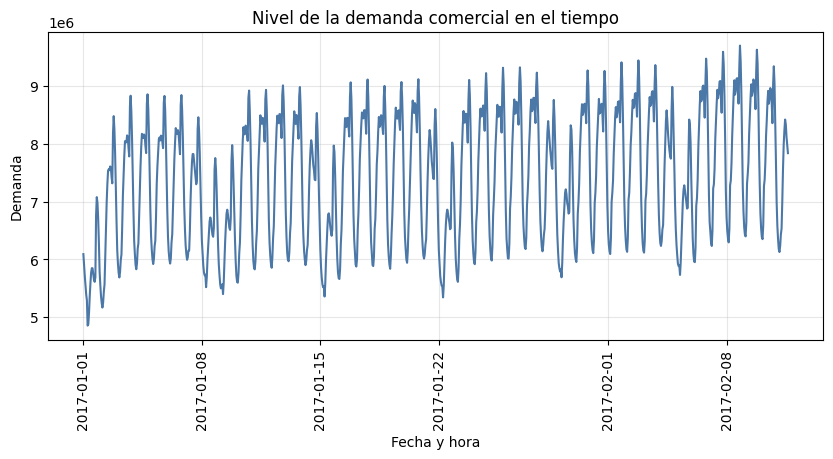

In [3]:
# La serie continua evidencia que el nivel cambia en el tiempo; por eso el clustering se concentra después en la forma diaria.

plt.figure(figsize=(10, 4))
plt.plot(series["instante"], series["demanda"], color="#4c78a8")
plt.xlabel("Fecha y hora")
plt.ylabel("Demanda")
plt.title("Nivel de la demanda comercial en el tiempo")
plt.xticks(rotation=90)
plt.grid(alpha=0.3)
plt.savefig("../submission/demanda-comercial.png", bbox_inches="tight")
plt.show()

In [4]:
# La normalización separa la forma diaria del nivel absoluto de demanda.

profiles = data.div(data.max(axis=1), axis=0)
profiles.head()

,H01,H02,H03,H04,H05,H06,H07,H08,H09,H10,...,H15,H16,H17,H18,H19,H20,H21,H22,H23,H24
Fecha,,,,,,,,,,,,,,,,,,,,,
2017-01-01,0.860468,0.831753,0.806556,0.782459,0.761498,0.747147,0.685407,0.688932,0.716857,0.757250,...,0.811766,0.797954,0.792513,0.803930,0.955237,1.0,0.986099,0.945951,0.888560,0.818686
2017-01-02,0.655213,0.632036,0.617666,0.608777,0.618894,0.641213,0.656315,0.713880,0.776693,0.822799,...,0.897247,0.894118,0.874921,0.862660,0.964699,1.0,0.972752,0.923858,0.851347,0.785262
2017-01-03,0.697234,0.670548,0.652387,0.643493,0.653950,0.677447,0.688545,0.740741,0.802727,0.844419,...,0.922219,0.918660,0.897579,0.880926,0.979355,1.0,0.969054,0.916246,0.842395,0.774150
2017-01-04,0.713507,0.687580,0.666503,0.657754,0.668799,0.697754,0.708417,0.760436,0.819030,0.858744,...,0.921476,0.917807,0.898704,0.885023,0.981970,1.0,0.971878,0.919550,0.843231,0.771789
2017-01-05,0.724097,0.697718,0.679460,0.670122,0.680001,0.704808,0.715892,0.763014,0.827406,0.862729,...,0.922101,0.921193,0.908368,0.897554,0.987087,1.0,0.971441,0.913017,0.838589,0.773288


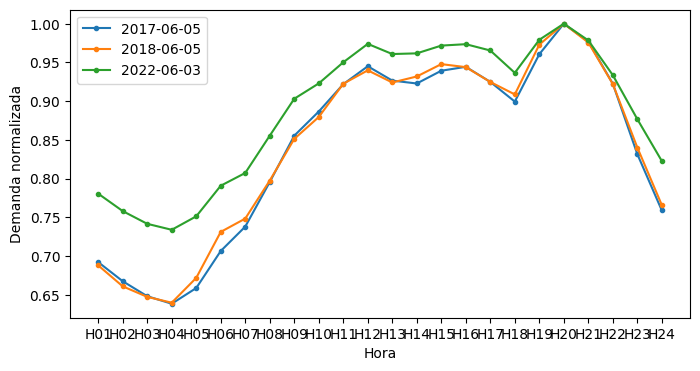

In [5]:
# Los perfiles de días comparables muestran por qué conviene agrupar formas y no niveles.

plt.figure(figsize=(8, 4))
for date in ["2017-06-05", "2018-06-05", "2022-06-03"]:
    plt.plot(hours, profiles.loc[date], marker=".", label=date)
plt.xlabel("Hora")
plt.ylabel("Demanda normalizada")
plt.legend()
plt.savefig("../submission/demanda-comercial-patrones-ejemplo.png", bbox_inches="tight")
plt.show()

In [6]:
# La silueta contrasta alternativas de segmentación de los perfiles diarios.

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

rows=[]
for n_clusters in range(2, 6):
    model=KMeans(n_clusters=n_clusters, n_init=10, random_state=0).fit(profiles)
    rows.append({"n_clusters": n_clusters, "silhouette_score": silhouette_score(profiles, model.labels_)})
cluster_selection=pd.DataFrame(rows)
cluster_selection

,n_clusters,silhouette_score
0,2,0.520248
1,3,0.382215
2,4,0.356467
3,5,0.334157


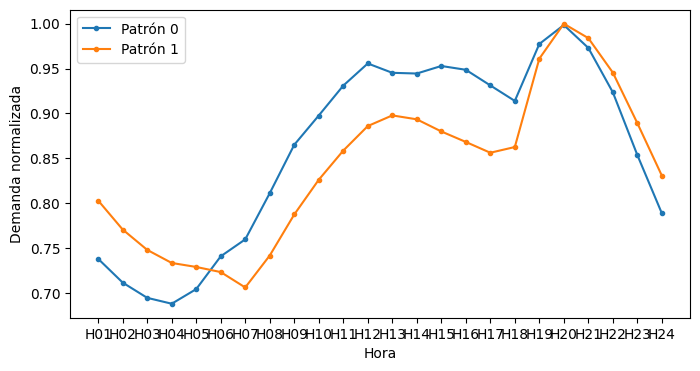

In [7]:
# Dos patrones maximizan la silueta y permiten una interpretación inicial de los perfiles.

kmeans=KMeans(n_clusters=2, n_init=10, random_state=0).fit(profiles)
plt.figure(figsize=(8, 4))
for cluster, center in enumerate(kmeans.cluster_centers_):
    plt.plot(hours, center, marker=".", label=f"Patrón {cluster}")
plt.xlabel("Hora")
plt.ylabel("Demanda normalizada")
plt.legend()
plt.savefig("../submission/demanda-comercial-perfiles.png", bbox_inches="tight")
plt.show()

In [8]:
# Las asignaciones se conservan para contar su frecuencia por día de semana; un cluster no identifica de forma determinista un día.

day_names = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
daily_patterns = pd.DataFrame({"Fecha": profiles.index, "cluster": kmeans.labels_})
daily_patterns["day_of_week"] = pd.Categorical(
    pd.to_datetime(daily_patterns["Fecha"]).dt.dayofweek.map(dict(enumerate(day_names))),
    categories=day_names,
    ordered=True,
)
daily_patterns

,Fecha,cluster,day_of_week
0,2017-01-01,1,Domingo
1,2017-01-02,1,Lunes
2,2017-01-03,0,Martes
3,2017-01-04,0,Miércoles
4,2017-01-05,0,Jueves
...,...,...,...
2064,2022-08-27,0,Sábado
2065,2022-08-28,1,Domingo
2066,2022-08-29,0,Lunes
2067,2022-08-30,0,Martes


In [9]:
# Los conteos ordenados revelan el patrón semanal emergente dentro de cada cluster sin convertirlo en una regla fija.

for cluster in [0, 1]:
    day_counts = (
        daily_patterns.loc[daily_patterns["cluster"] == cluster, "day_of_week"]
        .value_counts()
        .reindex(day_names, fill_value=0)
    )
    print(f"Cluster {cluster}")
    display(day_counts)

days_cluster_0 = (
    daily_patterns.loc[daily_patterns["cluster"] == 0, "day_of_week"]
    .value_counts()
    .reindex(day_names, fill_value=0)
)
days_cluster_1 = (
    daily_patterns.loc[daily_patterns["cluster"] == 1, "day_of_week"]
    .value_counts()
    .reindex(day_names, fill_value=0)
)

Cluster 0


day_of_week
Lunes        229
Martes       283
Miércoles    284
Jueves       284
Viernes      278
Sábado       267
Domingo        0
Name: count, dtype: int64

Cluster 1


day_of_week
Lunes         67
Martes        13
Miércoles     12
Jueves        11
Viernes       17
Sábado        28
Domingo      296
Name: count, dtype: int64

In [10]:
# Se guardan las evidencias de la segmentación para discutir la interpretación durante la clase.

from pathlib import Path
output=Path("../submission")
cluster_selection.to_csv(output / "cluster-selection.csv", index=False)
daily_patterns.to_csv(output / "demanda-comercial-clusters.csv", index=False)
day_summary=pd.DataFrame({"day_of_week": day_names, "cluster_0_days": days_cluster_0, "cluster_1_days": days_cluster_1})
day_summary.to_csv(output / "demanda-comercial-dias.csv", index=False)
pd.DataFrame({"Fecha": [profiles.index[-1]], "cluster_asignado": [kmeans.predict(profiles.iloc[[-1]])[0]]}).to_csv(output / "perfil-recibido.csv", index=False)